# Fill Level Prediction — draft

Goal: build a model that **predicts** a container's fill level (not just
reads the current value), and use that prediction to decide which
containers should be included in today's collection route.

We compare two approaches:
- **Level 1** — fixed rule, based on the current fill level (baseline, no AI)
- **Level 2** — predictive model, based on the estimated fill level for the next day


## Stage 1: The difference between a "rule" and a "prediction"

**Why is "if fill_level > 80%, collect" a rule, and not Artificial Intelligence?**

A fixed rule applies a deterministic condition, written manually by us, to
an already known value (the current, measured level). It doesn't learn
anything from data, doesn't adapt, and doesn't generalize — its behaviour
is identical today, tomorrow, and a year from now, regardless of what
patterns appear in the data.

A **prediction** system (AI/ML), on the other hand, learns a relationship
from a history of data (e.g. how fill_level evolves over time) and
**estimates** a value we haven't measured yet — tomorrow's level, not
today's. It doesn't receive an "if X then Y" rule written by us; it
**derives** one from patterns observed in data, and the result is a
probabilistic estimate, not a certainty.

In practice: the rule reacts to what has already happened (the container
is already full); the prediction anticipates what's about to happen,
which can prevent a container from reaching 100% without being included
in the route in time.


## Stage 2: Verifying and preparing the data

### Step 2.1 — Load and check the structure

In [1]:
import pandas as pd
import numpy as np

DATA_FILE = "data/processed/data_geocoded.csv"

df = pd.read_csv(DATA_FILE)

print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head()

Rows: 638
Columns: ['route_id', 'Car', 'Datetime', 'Id', 'Capacity', 'Address', 'fill_level', 'Latitude', 'Longitude']


,route_id,Car,Datetime,Id,Capacity,Address,fill_level,Latitude,Longitude
0,1,SB-25-SOM,NaN,NaN,NaN,"Strada Șelimbărului 90, Cisnădie, Romania",NaN,45.731536,24.177939
1,1,SB-25-SOM,2024-10-15 06:14:38+00:00,O5AHDP,1.100L,"Calea Șurii Mari 39 B, Sibiu, Romania",51.0,45.823039,24.147704
2,1,SB-25-SOM,2024-10-15 06:19:38+00:00,O5AHDP,1.100L,"Calea Șurii Mari 39 B, Sibiu, Romania",92.0,45.823039,24.147704
3,1,SB-25-SOM,2024-10-15 06:32:00+00:00,NH7XHL,1.100L,"Calea Șurii Mari 39, Sibiu, Romania",14.0,45.823031,24.147618
4,1,SB-25-SOM,2024-10-15 06:38:19+00:00,HPDZUE,1.100L,"Strada Căprioarelor 1, Sibiu, Romania",71.0,45.814286,24.149770


### Step 2.2 — Rows with missing fill_level

We don't automatically assume these are errors — we investigate their
position within each route (route_id), following the order already
present in the dataset (which reflects the actual chronological order of
collection, with the depot start/end points added at both ends).

In [2]:
missing = df[df["fill_level"].isna()]
print(f"Rows with missing fill_level: {len(missing)}")
missing[["route_id", "Car", "Address", "Datetime", "Id"]]

Rows with missing fill_level: 6


,route_id,Car,Address,Datetime,Id
0,1,SB-25-SOM,"Strada Șelimbărului 90, Cisnădie, Romania",NaN,NaN
333,1,SB-25-SOM,"DN1 FN, Cristian 557085",NaN,NaN
334,2,SB-30-SOM,"Strada Șelimbărului 90, Cisnădie, Romania",NaN,NaN
532,2,SB-30-SOM,"DN1 FN, Cristian 557085",NaN,NaN
533,3,SB-45-SOM,"Strada Șelimbărului 90, Cisnădie, Romania",NaN,NaN
637,3,SB-45-SOM,"DN1 FN, Cristian 557085",NaN,NaN


In [3]:
# Their position within each route (first / last row?)
for route_id, group in df.groupby("route_id", sort=False):
    print(f"Route {route_id}: {len(group)} rows.")
    print(f"  First row -> fill_level missing: {pd.isna(group['fill_level'].iloc[0])}, "
          f"Address: {group['Address'].iloc[0]}")
    print(f"  Last row -> fill_level missing: {pd.isna(group['fill_level'].iloc[-1])}, "
          f"Address: {group['Address'].iloc[-1]}")

Route 1: 334 rows.
  First row -> fill_level missing: True, Address: Strada Șelimbărului 90, Cisnădie, Romania
  Last row -> fill_level missing: True, Address: DN1 FN, Cristian 557085
Route 2: 199 rows.
  First row -> fill_level missing: True, Address: Strada Șelimbărului 90, Cisnădie, Romania
  Last row -> fill_level missing: True, Address: DN1 FN, Cristian 557085
Route 3: 105 rows.
  First row -> fill_level missing: True, Address: Strada Șelimbărului 90, Cisnădie, Romania
  Last row -> fill_level missing: True, Address: DN1 FN, Cristian 557085


**Confirmed**: on every route, exactly the first and last row have a
missing `fill_level` — they correspond to the collection truck's
depot departure/arrival points, not measurement errors. They are
structural points, not containers, and we **don't delete them** — we
mark them.

**Marking rule**: for each route (already in chronological order in the
data), the first row = departure point, the last row = arrival point,
everything else = container.

In [4]:
df["point_type"] = "container"

for route_id, group in df.groupby("route_id", sort=False):
    first_idx = group.index[0]
    last_idx = group.index[-1]
    df.loc[first_idx, "point_type"] = "depot_departure"
    df.loc[last_idx, "point_type"] = "depot_arrival"

print(df["point_type"].value_counts())

point_type
container          632
depot_departure      3
depot_arrival        3
Name: count, dtype: int64


**Check**: we should have exactly 2 structural points per route
(1 departure + 1 arrival) × number of routes.

In [5]:
n_routes = df["route_id"].nunique()
n_structural_expected = 2 * n_routes
n_structural_actual = (df["point_type"] != "container").sum()

print(f"Routes: {n_routes}")
print(f"Expected structural points: {n_structural_expected}")
print(f"Found structural points: {n_structural_actual}")
assert n_structural_expected == n_structural_actual, "Mismatch!"
print("OK — matches.")

Routes: 3
Expected structural points: 6
Found structural points: 6
OK — matches.


### Step 2.3 — Container subset

We keep only the rows marked as `container`, dropping any row missing
its identifier, capacity, or fill level (extra safety check).

In [6]:
containers = df[df["point_type"] == "container"].copy()
containers = containers.dropna(subset=["Id", "Capacity", "fill_level"])
containers = containers.reset_index(drop=True)

# Note: Id is NOT always unique (some containers were read twice) — we use
# the row position as a synthetic, guaranteed-unique key for the
# calculations that follow (simulated history, prediction). Id remains
# only for display purposes.
containers["uid"] = containers.index

print(f"Containers in subset: {len(containers)}")
print(f"Duplicate (non-unique) Ids: {(containers['Id'].value_counts() > 1).sum()}")
containers.head()

Containers in subset: 632
Duplicate (non-unique) Ids: 6


,route_id,Car,Datetime,Id,Capacity,Address,fill_level,Latitude,Longitude,point_type,uid
0,1,SB-25-SOM,2024-10-15 06:14:38+00:00,O5AHDP,1.100L,"Calea Șurii Mari 39 B, Sibiu, Romania",51.0,45.823039,24.147704,container,0
1,1,SB-25-SOM,2024-10-15 06:19:38+00:00,O5AHDP,1.100L,"Calea Șurii Mari 39 B, Sibiu, Romania",92.0,45.823039,24.147704,container,1
2,1,SB-25-SOM,2024-10-15 06:32:00+00:00,NH7XHL,1.100L,"Calea Șurii Mari 39, Sibiu, Romania",14.0,45.823031,24.147618,container,2
3,1,SB-25-SOM,2024-10-15 06:38:19+00:00,HPDZUE,1.100L,"Strada Căprioarelor 1, Sibiu, Romania",71.0,45.814286,24.149770,container,3
4,1,SB-25-SOM,2024-10-15 06:46:41+00:00,BNY3U5,120L,"Strada Lungă 71, Sibiu, Romania",60.0,45.810144,24.147105,container,4


### Step 2.8 — Final check

The number of rows in the container subset must equal the total number
of rows, minus the number of structural points.

In [7]:
expected = len(df) - n_structural_actual
print(f"Total rows: {len(df)}")
print(f"Structural points: {n_structural_actual}")
print(f"Expected in subset: {expected}")
print(f"Actual in subset: {len(containers)}")
assert expected == len(containers), "Mismatch!"
print("OK — matches.")

Total rows: 638
Structural points: 6
Expected in subset: 632
Actual in subset: 632
OK — matches.


## Stage 3: Level 1 — The simple rule (baseline, no AI)

### Step 3.1 — Fill-level thresholds

We start from 80%, but differentiate by capacity: a **1,100L** container
usually serves commercial/high-traffic areas, where overflowing has a
bigger impact (odor, blockages, hygiene risk) — so we pick a **lower**
threshold (collect earlier). A small residential container (**120L**) can
wait a bit longer, since the impact of overflowing is local and minor.

In [8]:
THRESHOLDS = {
    "120L": 85,
    "240L": 80,
    "1.100L": 70,
}

print("Collection thresholds, by capacity:")
for cap, threshold in THRESHOLDS.items():
    print(f"  {cap}: {threshold}%")

Collection thresholds, by capacity:
  120L: 85%
  240L: 80%
  1.100L: 70%


### Step 3.2 — Filter on the current threshold

In [9]:
containers["threshold"] = containers["Capacity"].map(THRESHOLDS)
rule_collection = containers[containers["fill_level"] >= containers["threshold"]].copy()

### Step 3.3 — Number of containers selected (reference)

In [10]:
n_rule = len(rule_collection)
print(f"Containers selected by the simple rule: {n_rule}")
rule_collection[["Id", "Address", "Capacity", "fill_level", "threshold"]].head(10)

Containers selected by the simple rule: 138


,Id,Address,Capacity,fill_level,threshold
1,O5AHDP,"Calea Șurii Mari 39 B, Sibiu, Romania",1.100L,92.0,70
3,HPDZUE,"Strada Căprioarelor 1, Sibiu, Romania",1.100L,71.0,70
6,HLQKX5,"Strada Țiglarilor 12, Sibiu, Romania",1.100L,82.0,70
7,MO25A3,"Strada Țiglarilor 12, Sibiu, Romania",1.100L,86.0,70
8,OVR7LU,"Strada Țiglarilor 12, Sibiu, Romania",1.100L,74.0,70
10,MNQ5,"Strada Țiglarilor 24, Sibiu, Romania",120L,87.0,85
11,R2LY,"Strada Țiglarilor 28, Sibiu, Romania",120L,99.0,85
17,FZRC,"Strada Eschile 17, Sibiu, Romania",120L,87.0,85
28,LTVP5I,"Strada Eschile 49, Sibiu, Romania",120L,88.0,85
30,XJTO,"Strada Traian Demetrescu 142, Sibiu, Romania",120L,90.0,85


### Step 3.4 — Save the result

In [11]:
import os
os.makedirs("data/processed", exist_ok=True)
rule_collection.to_csv("data/processed/collection_simple_rule.csv", index=False)
print("Saved: data/processed/collection_simple_rule.csv")

Saved: data/processed/collection_simple_rule.csv


## Stage 4: Preparing a history for prediction

### Step 4.1 — Why a single measurement isn't enough

We have a single `fill_level` value per container, from a single day. A
prediction model learns a **relationship over time** (how the fill level
evolves from one day to the next) — from a single point there is no
variation, no slope, no pattern to observe. Essentially, the model would
have nothing to learn from; it would need at least 2 points just to
compute a rate of change, and many more to distinguish real signal from
noise.

### Steps 4.2-4.4 — Simulating a history

We simulate an artificial history of **30 days** per container, starting
from the actual measured value (day 0, the most recent known day) and
going **backward** in time, subtracting a daily fill rate (with random
variation, so the trajectory isn't perfectly linear).

### Step 4.3 — Daily fill rate, by capacity

A large, **commercial** container (1,100L) is used by more people/
businesses at once, so it fills up faster per day than a small
**residential** one (120L), used by few households.

In [12]:
DAILY_RATES = {
    "120L": (3, 6),      # % per day
    "240L": (4, 7),
    "1.100L": (6, 10),
}

N_DAYS = 30
np.random.seed(42)

history_rows = []

for _, row in containers.iterrows():
    capacity = row["Capacity"]
    rate_min, rate_max = DAILY_RATES[capacity]

    level = row["fill_level"]  # day 0 = actual measured value
    container_history = [(0, level)]

    for day in range(-1, -N_DAYS, -1):
        rate = np.random.uniform(rate_min, rate_max)
        noise = np.random.normal(0, 1.5)  # small variation, not perfectly linear
        level = level - rate + noise
        level = min(max(level, 0), 100)
        container_history.append((day, level))

    for day, val in container_history:
        history_rows.append({
            "uid": row["uid"],
            "Id": row["Id"],
            "Capacity": capacity,
            "day": day,
            "simulated_fill_level": val,
        })

history = pd.DataFrame(history_rows)
print(f"Simulated history rows: {len(history)} ({len(containers)} containers x {N_DAYS} days)")
history.head()

Simulated history rows: 18960 (632 containers x 30 days)


,uid,Id,Capacity,day,simulated_fill_level
0,0,O5AHDP,1.100L,0,51.000000
1,0,O5AHDP,1.100L,-1,41.834019
2,0,O5AHDP,1.100L,-2,35.688395
3,0,O5AHDP,1.100L,-3,29.874622
4,0,O5AHDP,1.100L,-4,22.558105


### Step 4.5 — Save the simulated history (separate file)

In [13]:
history.to_csv("data/processed/simulated_history.csv", index=False)
print("Saved: data/processed/simulated_history.csv")

Saved: data/processed/simulated_history.csv


### Step 4.6 — Check: evolution for 2-3 containers

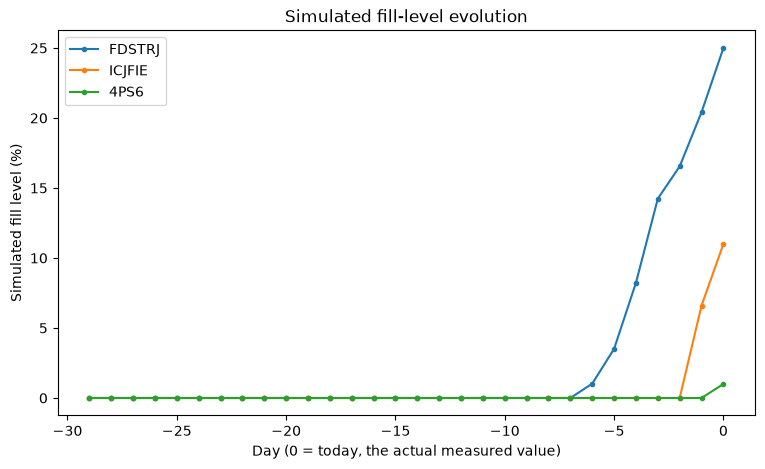

In [14]:
import matplotlib.pyplot as plt

sample_uids = containers["uid"].sample(3, random_state=1).tolist()

fig, ax = plt.subplots(figsize=(9, 5))
for uid in sample_uids:
    sub = history[history["uid"] == uid].sort_values("day")
    displayed_id = sub["Id"].iloc[0]
    ax.plot(sub["day"], sub["simulated_fill_level"], marker="o", markersize=3, label=displayed_id)

ax.set_xlabel("Day (0 = today, the actual measured value)")
ax.set_ylabel("Simulated fill level (%)")
ax.set_title("Simulated fill-level evolution")
ax.legend()
plt.show()

As expected: the level increases progressively as we approach day 0
(the real value), with small variations from one day to the next — not
sudden jumps between very different values.

### Step 4.7 — Limitation of this step

**The history above is simulated, not real.** We generated it starting
from a single real measurement plus assumptions (a daily-rate range per
capacity) — not from a series of actual, day-by-day measurements. Any
model trained on this history directly inherits the quality of those
assumptions: if the rates chosen in Step 4.3 don't reflect the real
behaviour of Sibiu's containers, the model's predictions won't be
realistic either — the model will correctly learn *the pattern of our
simulation*, not necessarily real-world behaviour.

## Stage 5: Training the prediction model

### Steps 5.1-5.2 — Building the variables (features + target)

- **Features**: today's level, yesterday's level, the difference between
  them (the growth rate)
- **Target**: tomorrow's level

In [15]:
sorted_history = history.sort_values(["uid", "day"]).reset_index(drop=True)

sorted_history["previous_day_level"] = sorted_history.groupby("uid")["simulated_fill_level"].shift(1)
sorted_history["next_day_level"] = sorted_history.groupby("uid")["simulated_fill_level"].shift(-1)
sorted_history["growth_rate"] = (
    sorted_history["simulated_fill_level"] - sorted_history["previous_day_level"]
)

sorted_history.head()

,uid,Id,Capacity,day,simulated_fill_level,previous_day_level,next_day_level,growth_rate
0,0,O5AHDP,1.100L,-29,0.0,NaN,0.0,NaN
1,0,O5AHDP,1.100L,-28,0.0,0.0,0.0,0.0
2,0,O5AHDP,1.100L,-27,0.0,0.0,0.0,0.0
3,0,O5AHDP,1.100L,-26,0.0,0.0,0.0,0.0
4,0,O5AHDP,1.100L,-25,0.0,0.0,0.0,0.0


### Step 5.3 — Drop rows without enough context

The first day of each container's history has no previous day (we can't
compute the growth rate); the last day has no next day (no target to
predict).

In [16]:
model_data = sorted_history.dropna(
    subset=["previous_day_level", "next_day_level", "growth_rate"]
).copy()

print(f"Rows usable for training: {len(model_data)}")

Rows usable for training: 17696


### Step 5.4 — Train/test split

**Why is it wrong to evaluate a model on the same data it was trained
on?** The model could simply "memorize" the training data (including its
noise) without having learned a general pattern — we'd get an
artificially low error that says nothing about how the model would
perform on new, unseen data. Testing on a separate set the model hasn't
seen during training is the only honest way to estimate real-world
performance.

In [17]:
from sklearn.model_selection import train_test_split

FEATURES = ["simulated_fill_level", "previous_day_level", "growth_rate"]
TARGET = "next_day_level"

X = model_data[FEATURES]
y = model_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {len(X_train)} rows | Testing: {len(X_test)} rows")

Training: 14156 rows | Testing: 3540 rows


### Step 5.5 — Choosing and training the model

We choose **linear regression** — simple, fast, easy to interpret (the
coefficients directly show each variable's impact), a reasonable starting
point for a relationship that looks nearly linear (the fill level
increases steadily over time, by construction of our simulation).

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:", dict(zip(FEATURES, model.coef_)))
print("Intercept:", model.intercept_)

Coefficients: {'simulated_fill_level': np.float64(0.905516324943865), 'previous_day_level': np.float64(0.1147895230975075), 'growth_rate': np.float64(0.7907268018464133)}
Intercept: 0.447200643876009


### Step 5.6 — Evaluation on the test set (MAE)

In [19]:
from sklearn.metrics import mean_absolute_error

y_pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)

print(f"Mean Absolute Error (MAE) on the test set: {mae:.2f} percentage points")

Mean Absolute Error (MAE) on the test set: 1.00 percentage points


### Step 5.7 — Interpretation

An MAE of a few percentage points means: **on average, the model's
prediction for the next day is off by about that many percentage points**
from the actual (simulated) value. For the collection decision
(threshold ~70-85%), an error of a few points is generally acceptable —
it won't change the decision for containers clearly below or above the
threshold, but it could matter for those right at the boundary.
Important caveat: this error reflects how well the model reproduces *our
simulation's pattern*, not necessarily its real-world accuracy in the
field (see the limitation noted in Step 4.7).

## Stage 6: Applying the prediction to the collection decision

### Steps 6.1-6.2 — Most recent state + input variables

For each real container, we take the last known day from the simulated
history (day 0 = the actual measured value) and the previous day
(day -1), to build the same variables used during training.

In [20]:
day_0 = sorted_history[sorted_history["day"] == 0][["uid", "Id", "simulated_fill_level"]]
day_minus1 = sorted_history[sorted_history["day"] == -1][["uid", "simulated_fill_level"]]
day_minus1 = day_minus1.rename(columns={"simulated_fill_level": "previous_day_level"})

current_state = day_0.merge(day_minus1, on="uid", how="inner")
current_state["growth_rate"] = (
    current_state["simulated_fill_level"] - current_state["previous_day_level"]
)

print(f"Containers with enough context for prediction: {len(current_state)}")
current_state.head()

Containers with enough context for prediction: 632


,uid,Id,simulated_fill_level,previous_day_level,growth_rate
0,0,O5AHDP,51.0,41.834019,9.165981
1,1,O5AHDP,92.0,84.415594,7.584406
2,2,NH7XHL,14.0,4.510252,9.489748
3,3,HPDZUE,71.0,66.489046,4.510954
4,4,BNY3U5,60.0,55.028590,4.971410


### Step 6.3 — The model's prediction

In [21]:
X_predict = current_state[FEATURES]
current_state["predicted_fill_level"] = model.predict(X_predict)
current_state["predicted_fill_level"] = current_state["predicted_fill_level"].clip(0, 100)

current_state.head()

,uid,Id,simulated_fill_level,previous_day_level,growth_rate,predicted_fill_level
0,0,O5AHDP,51.0,41.834019,9.165981,58.678427
1,1,O5AHDP,92.0,84.415594,7.584406,99.441921
2,2,NH7XHL,14.0,4.510252,9.489748,21.145957
3,3,HPDZUE,71.0,66.489046,4.510954,75.938038
4,4,BNY3U5,60.0,55.028590,4.971410,65.025913


### Step 6.4 — Applying the threshold to the PREDICTED value

In [22]:
current_state = current_state.merge(
    containers[["uid", "Capacity", "threshold", "Address"]], on="uid", how="left"
)

predictive_collection = current_state[
    current_state["predicted_fill_level"] >= current_state["threshold"]
].copy()

### Step 6.5 — Number of containers selected

In [23]:
n_predictive = len(predictive_collection)
print(f"Containers selected by the predictive model: {n_predictive}")
predictive_collection[["Id", "Address", "Capacity", "simulated_fill_level",
                         "predicted_fill_level", "threshold"]].head(10)

Containers selected by the predictive model: 150


,Id,Address,Capacity,simulated_fill_level,predicted_fill_level,threshold
1,O5AHDP,"Calea Șurii Mari 39 B, Sibiu, Romania",1.100L,92.0,99.441921,70
3,HPDZUE,"Strada Căprioarelor 1, Sibiu, Romania",1.100L,71.0,75.938038,70
6,HLQKX5,"Strada Țiglarilor 12, Sibiu, Romania",1.100L,82.0,90.890639,70
7,MO25A3,"Strada Țiglarilor 12, Sibiu, Romania",1.100L,86.0,93.608346,70
8,OVR7LU,"Strada Țiglarilor 12, Sibiu, Romania",1.100L,74.0,80.456819,70
9,M4FF,"Strada Țiglarilor 20, Sibiu, Romania",240L,74.0,80.881235,80
10,MNQ5,"Strada Țiglarilor 24, Sibiu, Romania",120L,87.0,93.632559,85
11,R2LY,"Strada Țiglarilor 28, Sibiu, Romania",120L,99.0,100.000000,85
17,FZRC,"Strada Eschile 17, Sibiu, Romania",120L,87.0,93.594466,85
28,LTVP5I,"Strada Eschile 49, Sibiu, Romania",120L,88.0,94.183239,85


### Step 6.6 — Save the result (separate file from Stage 3)

In [24]:
predictive_collection.to_csv("data/processed/collection_predictive.csv", index=False)
print("Saved: data/processed/collection_predictive.csv")

Saved: data/processed/collection_predictive.csv


## Stage 7: Comparing the two methods

### Step 7.1 — Number of containers selected, side by side

Simple rule (current level >= threshold):     138 containers
Predictive model (predicted tomorrow >= threshold): 150 containers


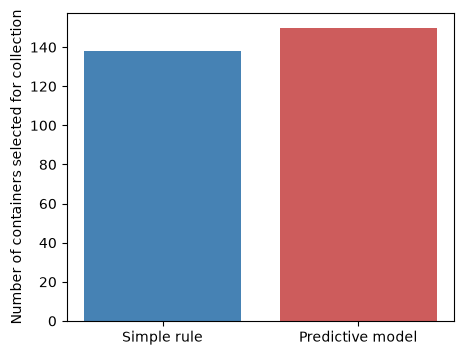

In [25]:
print(f"Simple rule (current level >= threshold):     {n_rule} containers")
print(f"Predictive model (predicted tomorrow >= threshold): {n_predictive} containers")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Simple rule", "Predictive model"], [n_rule, n_predictive],
       color=["steelblue", "indianred"])
ax.set_ylabel("Number of containers selected for collection")
plt.show()

### Step 7.2 — Containers ONLY in the predictive list

These are below the threshold today, but the model estimates they'll go
over the threshold tomorrow.

In [26]:
rule_ids = set(rule_collection["uid"])
predictive_ids = set(predictive_collection["uid"])

only_predictive = predictive_ids - rule_ids
print(f"Containers only in the predictive list: {len(only_predictive)}")

current_state[current_state["uid"].isin(only_predictive)][
    ["Id", "Address", "simulated_fill_level", "predicted_fill_level", "threshold"]
]

Containers only in the predictive list: 12


,Id,Address,simulated_fill_level,predicted_fill_level,threshold
9,M4FF,"Strada Țiglarilor 20, Sibiu, Romania",74.0,80.881235,80
60,A4NQ,"Strada Lăcrămioarelor 16, Sibiu, Romania",83.0,89.641254,85
96,6HTD,"Strada Țiglarilor 84, Sibiu, Romania",84.0,87.764131,85
187,FN4Z,"Strada Lutului 29, Sibiu, Romania",83.0,89.611151,85
278,NNJ2KY,"Strada General Bălan 18, Sibiu, Romania",81.0,86.893089,85
316,OCKI,"Strada Simion Bărnuțiu 41, Sibiu, Romania",83.0,88.720353,85
323,GJZX,"Strada Simion Bărnuțiu 28, Sibiu, Romania",81.0,85.676144,85
388,F376,"Strada Rampa Ștefan cel Mare 8, Sibiu, Romania",84.0,87.201074,85
517,KAN4FM,"Strada Ștefan cel Mare 156 A, Sibiu, Romania",68.0,74.306430,70
521,E7LF5S,"Strada Ștefan cel Mare 156, Sibiu, Romania",68.0,75.675405,70


**The risk of NOT collecting them** (if we relied only on the
simple rule): these containers would be left out of today's route, but
could go over the threshold before the next scheduled collection — risk
of overflow, odor, or an unplanned emergency pickup, which is needlessly
expensive. The prediction lets us include them **preemptively**, in the
same run as the others, more efficiently.

### Step 7.3 — Containers ONLY in the rule-based list

These are over the threshold today, but the model doesn't include them
(tomorrow's prediction is below the threshold).

In [27]:
only_rule = rule_ids - predictive_ids
print(f"Containers only in the rule-based list: {len(only_rule)}")

current_state[current_state["uid"].isin(only_rule)][
    ["Id", "Address", "simulated_fill_level", "predicted_fill_level", "threshold"]
]

Containers only in the rule-based list: 0


,Id,Address,simulated_fill_level,predicted_fill_level,threshold


Why the model might consider them not urgent: in our simulated
data, the fill level always increases monotonically, so a case like this
is unlikely to show up — if it does, it's more likely a sign of
noise/model imprecision (linear regression can slightly underestimate
very steep slopes) than an actual decrease in fill level. In a real-world
scenario (with genuine history), a case like this could arise if a
container's fill rate has recently slowed down (e.g. a lower-traffic
season).

### Step 7.4 — Conclusion

The predictive model brings practical value by **anticipating** rather
than just reacting: it identifies, ahead of time, containers that will
cross the threshold before the next route, allowing them to be included
preemptively and reducing the risk of overflow between collections. On
the other hand, the simple rule is easier to implement, fully
transparent, and doesn't depend on the quality of a history (real or
simulated) — an important advantage, since the history used here is
simulated, not measured. The real value of the prediction can only be
confirmed once genuine historical data is available, not artificially
generated.